In [1]:
import pandas as pd
import numpy as np

from google.colab import drive

drive.mount('/content/drive')



df = pd.read_csv("/content/drive/MyDrive/ML Projects/Project_3_Smart_Laptop_Price_Advisor_AI/data/laptop_price.csv")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [2]:
df.shape #To check the total number of Columns and Rows.
df.columns # To check actual names of Columns and for any extra spacing also.
df.info() # To check the Missing values,Data types,Memory usage.
df.describe() # To Check numerical columns statistics examples Mean,Minimum,Maximum,Quartiles and Standard Deviation.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    object 
 3   name               893 non-null    object 
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    object 
 7   CPU                893 non-null    object 
 8   Ram                893 non-null    object 
 9   Ram_type           893 non-null    object 
 10  ROM                893 non-null    object 
 11  ROM_type           893 non-null    object 
 12  GPU                893 non-null    object 
 13  display_size       893 non-null    float64
 14  resolution_width   893 non-null    float64
 15  resolution_height  893 non-null    float64
 16  OS                 893 non

,Unnamed: 0.1,Unnamed: 0,price,spec_rating,display_size,resolution_width,resolution_height,warranty
count,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000
mean,467.135498,521.382979,79907.409854,69.379026,15.173751,2035.393057,1218.324748,1.079507
std,270.209769,299.916605,60880.043823,5.541555,0.939095,426.076009,326.756883,0.326956
min,0.000000,0.000000,9999.000000,60.000000,11.600000,1080.000000,768.000000,0.000000
25%,235.000000,265.000000,44500.000000,66.000000,14.000000,1920.000000,1080.000000,1.000000
50%,467.000000,531.000000,61990.000000,69.323529,15.600000,1920.000000,1080.000000,1.000000
75%,702.000000,784.000000,90990.000000,71.000000,15.600000,1920.000000,1200.000000,1.000000
max,930.000000,1019.000000,450039.000000,89.000000,18.000000,3840.000000,3456.000000,3.000000


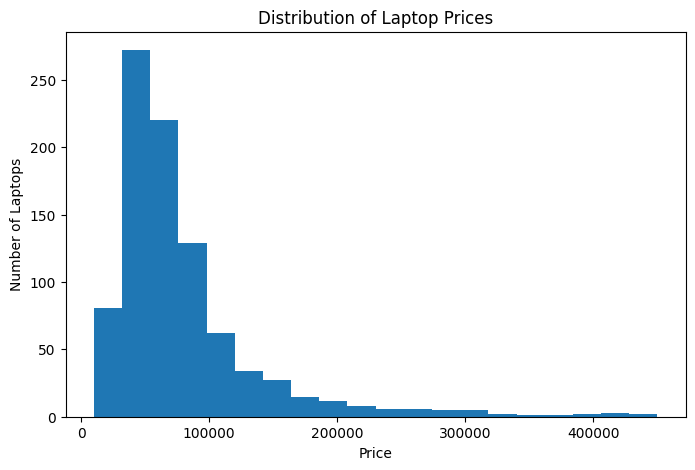

In [3]:
import matplotlib.pyplot as plt # In this graph we can find Laptop prices distribution as per number of Laptops.

plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=20)

plt.title("Distribution of Laptop Prices")

plt.xlabel("Price")

plt.ylabel("Number of Laptops")

plt.show()

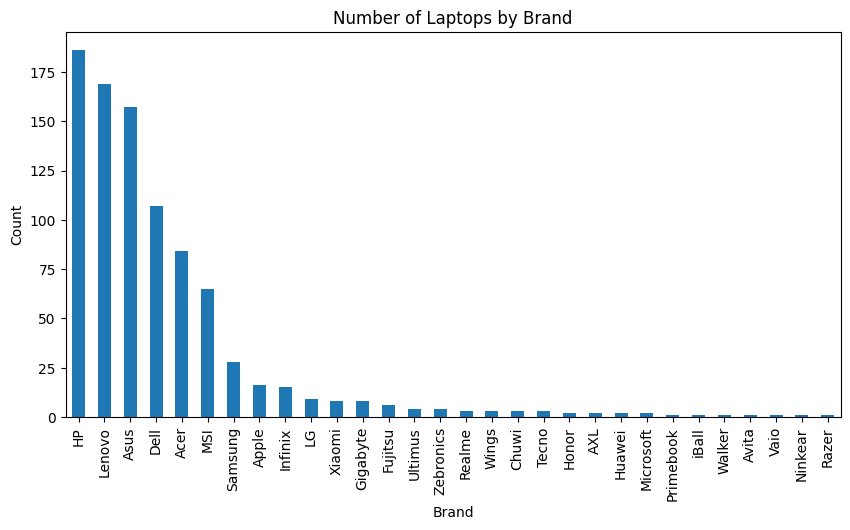

In [4]:
brand_counts = df["brand"].value_counts() # To find which Brand made a most Laptops.

brand_counts.plot(kind="bar", figsize=(10,5))

plt.title("Number of Laptops by Brand")

plt.xlabel("Brand")

plt.ylabel("Count")

plt.show()

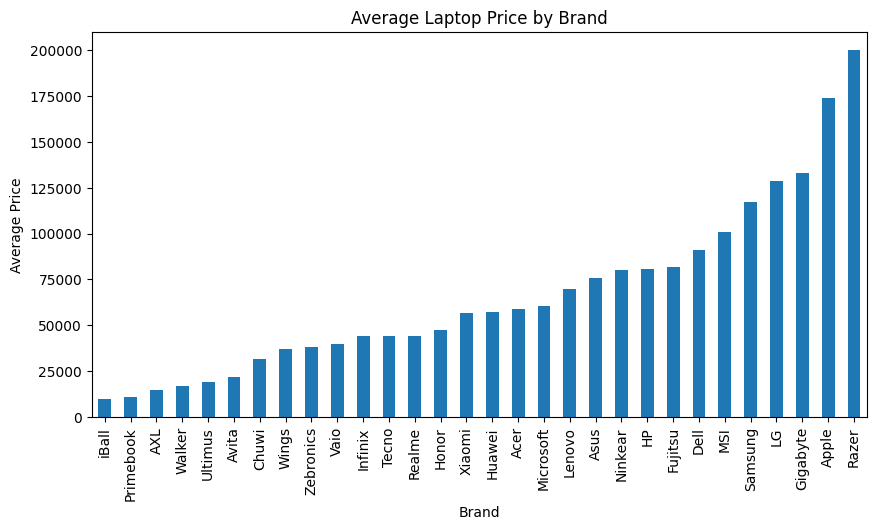

In [5]:
import matplotlib.pyplot as plt
brand_price = df.groupby("brand")["price"].mean()

brand_price = brand_price.sort_values()

plt.figure(figsize=(10,5))

brand_price.plot(kind="bar")

plt.title("Average Laptop Price by Brand")

plt.xlabel("Brand")

plt.ylabel("Average Price")

plt.show()

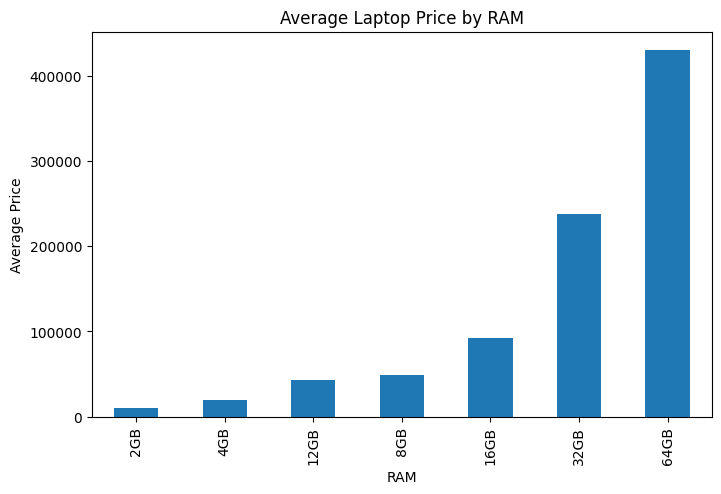

In [6]:
ram_price = df.groupby("Ram")["price"].mean().sort_values()

plt.figure(figsize=(8,5))

ram_price.plot(kind="bar")

plt.title("Average Laptop Price by RAM")

plt.xlabel("RAM")

plt.ylabel("Average Price")

plt.show()

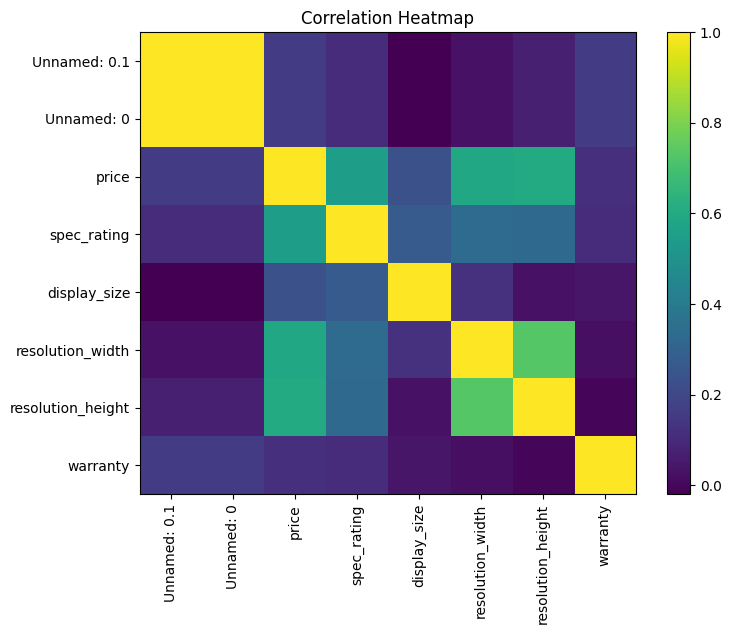

In [7]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

plt.figure(figsize=(8,6))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [8]:
# Feature Engineering starts from here.
df = df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"]) # Remove useless columns.

df.head()

,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [9]:
df["Ram"].unique()# Finding unique value from RAM Column

array(['8GB', '16GB', '4GB', '32GB', '2GB', '12GB', '64GB'], dtype=object)

In [10]:
df["Ram"] = df["Ram"].str.replace("GB", "") # (  .strip()  )It will remove space also if there is a space between 8 GB.

df["Ram"] = df["Ram"].astype(int)

In [11]:
df["Ram"].head()

,Ram
0,8
1,8
2,8
3,16
4,8


In [12]:
df["Ram"].dtype

dtype('int64')

In [13]:
df["ROM"].unique()

array(['512GB', '256GB', '128GB', '64GB', '1TB', '32GB', '2TB'],
      dtype=object)

In [14]:
def convert_rom(value): #Its a function use to convert TB into GB and also use float()To support future decimal storage values like 1.5TB.

    if "TB" in value:
        number = float(value.replace("TB", ""))
        return int(number * 1024)

    else:
        return int(value.replace("GB", ""))

In [15]:
df["ROM"] = df["ROM"].apply(convert_rom)

In [16]:
df["ROM"].unique()

array([ 512,  256,  128,   64, 1024,   32, 2048])

In [17]:
df["CPU"].unique()

array(['Hexa Core, 12 Threads', 'Hexa Core (2P + 4E), 8 Threads',
       'Dual Core, 4 Threads', '12 Cores (4P + 8E), 16 Threads',
       'Octa Core (4P + 4E)', 'Octa Core (4P + 4E), 12 Threads',
       '10 Cores (2P + 8E), 12 Threads', 'Dual Core, 2 Threads',
       'Octa Core', 'Quad Core, 8 Threads',
       '14 Cores (6P + 8E), 20 Threads', 'Octa Core, 16 Threads',
       'Octa Core, 8 Threads', '24 Cores (8P + 16E), 32 Threads',
       '10 Cores (6P + 4E), 16 Threads', '14 Cores, 20 Threads',
       'Quad Core, 4 Threads', 'Quad Core',
       '5 Cores (1P + 4E), 6 Threads', '16 Cores (8P + 8E), 24 Threads',
       '16 Cores, 32 Threads', '14 Cores (6P + 8E)', '12 Cores',
       '10 Cores, 12 Threads', 'Octa Core, 12 Threads',
       '10 Cores (8P + 2E)', '10 Cores', '24 Cores (8P + 16E)',
       '20 Threads'], dtype=object)

In [18]:
core_mapping = {
    "Dual": 2,
    "Quad": 4,
    "Hexa": 6,
    "Octa": 8
}

In [19]:
core_mapping

{'Dual': 2, 'Quad': 4, 'Hexa': 6, 'Octa': 8}

In [20]:
# It will both handle 'Hexa','Octa','Dual','Quad' and also handling '12 Cores','14 Cores'.

def extract_cpu_cores(value):
    parts = value.split()

    if parts[0].isdigit():
        return int(parts[0])

    if parts[0] in core_mapping:
            return core_mapping[parts[0]]

    return None

In [21]:
print(extract_cpu_cores("Hexa Core, 12 Threads"))

6


In [22]:
print(extract_cpu_cores("12 Cores (4P + 8E), 16 Threads"))

12


In [23]:
print(extract_cpu_cores("Random CPU"))

None


In [24]:
df["processor"].unique()

array(['5th Gen AMD Ryzen 5 5600H', '12th Gen Intel Core i3 1215U',
       '11th Gen Intel Core i3 1115G4', '12th Gen Intel Core i5 1240P',
       'Apple M1', '13th Gen Intel Core i5 13420H',
       '12th Gen Intel Core i5 12500H', '12th Gen Intel Core i7 1255U',
       'Intel Celeron  N4020', 'MediaTek MTK8788',
       '7th Gen AMD Ryzen 3 7320U', '11th Gen Intel Core i5 11400H ',
       '13th Gen Intel Core i9 13900H', '12th Gen Intel Core i5 12450H',
       '11th Gen Intel Core i5 11300H', 'Apple M2',
       '11th Gen Intel Core i5 1135G7 ', '5th Gen AMD Ryzen 7  5800H',
       '5th Gen AMD Ryzen 5 5500U', '3rd Gen AMD Athlon 3050U',
       'Intel Core i3 N305', '13th Gen Intel Core i7 1355U',
       '6th Gen AMD Ryzen 5 6600H', '13th Gen Intel Core i9 13900HX',
       '12th Gen Intel Core i7 12650H', '13th Gen Intel Core i5 1340P',
       '12th Gen Intel Core i5 1235U ', '13th Gen Intel Core i5 13450HX',
       '13th Gen Intel Core i9 13980HX', '11th Gen Intel Core i5 1135G7',
    

In [25]:
# CPU Brand Extraction Function
def extract_cpu_brand(processor):

    if pd.isna(processor):
        return "Other"

    processor = (str(processor).replace("\u200e", "").lower().strip())

    if "intel" in processor:
        return "Intel"

    elif "amd" in processor:
        return "AMD"

    elif "apple" in processor:
        return "Apple"

    elif "mediatek" in processor:
        return "MediaTek"

    else:
        return "Other"

In [26]:
df["CPU_Brand"] = df["processor"].apply(extract_cpu_brand)

In [27]:
df[["processor", "CPU_Brand"]].head(15)

,processor,CPU_Brand
0,5th Gen AMD Ryzen 5 5600H,AMD
1,12th Gen Intel Core i3 1215U,Intel
2,11th Gen Intel Core i3 1115G4,Intel
3,12th Gen Intel Core i5 1240P,Intel
4,Apple M1,Apple
5,12th Gen Intel Core i5 1240P,Intel
6,12th Gen Intel Core i3 1215U,Intel
7,13th Gen Intel Core i5 13420H,Intel
8,12th Gen Intel Core i5 12500H,Intel
9,12th Gen Intel Core i5 1240P,Intel


In [28]:
df["CPU_Brand"].value_counts()

,count
CPU_Brand,
Intel,615
AMD,265
Apple,12
MediaTek,1


In [29]:
# CPU_Family Feature Engineering
def extract_cpu_family(processor):

    if pd.isna(processor):
        return "Other"

    processor = (
        str(processor)
        .replace("\u200e", "")
        .lower()
        .strip()
    )

    if "core" in processor:
        return "Core"

    elif "ryzen" in processor:
        return "Ryzen"

    elif "celeron" in processor:
        return "Celeron"

    elif "pentium" in processor:
        return "Pentium"

    elif "athlon" in processor:
        return "Athlon"

    elif "atom" in processor:
        return "Atom"

    elif "apple" in processor:
        return "M Series"

    elif "mediatek" in processor:
        return "MediaTek"

    else:
        return "Other"

In [30]:
# Creating New Column CPU_Family
df["CPU_Family"] = df["processor"].apply(extract_cpu_family)

In [31]:
# New Column Verification
df[["processor", "CPU_Family"]].head(20)

,processor,CPU_Family
0,5th Gen AMD Ryzen 5 5600H,Ryzen
1,12th Gen Intel Core i3 1215U,Core
2,11th Gen Intel Core i3 1115G4,Core
3,12th Gen Intel Core i5 1240P,Core
4,Apple M1,M Series
5,12th Gen Intel Core i5 1240P,Core
6,12th Gen Intel Core i3 1215U,Core
7,13th Gen Intel Core i5 13420H,Core
8,12th Gen Intel Core i5 12500H,Core
9,12th Gen Intel Core i5 1240P,Core


In [32]:
df["CPU_Family"].value_counts()

,count
CPU_Family,
Core,583
Ryzen,257
Celeron,26
M Series,12
Athlon,8
Other,3
Pentium,3
MediaTek,1


In [33]:
# CPU_Series
def extract_cpu_series(processor):

    if pd.isna(processor):
        return "Other"

    processor = (
        str(processor)
        .replace("\u200e", "")
        .lower()
        .strip()
    )

    # Intel
    if "i9" in processor:
        return "i9"

    elif "i7" in processor:
        return "i7"

    elif "i5" in processor:
        return "i5"

    elif "i3" in processor:
        return "i3"

    # AMD Ryzen
    elif "ryzen 9" in processor:
        return "Ryzen 9"

    elif "ryzen 7" in processor:
        return "Ryzen 7"

    elif "ryzen 5" in processor:
        return "Ryzen 5"

    elif "ryzen 3" in processor:
        return "Ryzen 3"

    # Apple
    elif "m2 max" in processor:
        return "M2 Max"

    elif "m2 pro" in processor:
        return "M2 Pro"

    elif "m1 max" in processor:
        return "M1 Max"

    elif "m1 pro" in processor:
        return "M1 Pro"

    elif "m2" in processor:
        return "M2"

    elif "m1" in processor:
        return "M1"

    else:
        return "Other"

In [34]:
# Creating New Column CPU_Series
df["CPU_Series"] = df["processor"].apply(extract_cpu_series)

In [35]:
df["CPU_Series"].value_counts()

,count
CPU_Series,
i5,287
i7,148
Ryzen 5,128
i3,109
Ryzen 7,87
Other,44
i9,36
Ryzen 3,34
Ryzen 9,8


In [36]:
# CPU_Generation Feature Engineering
import re

def extract_cpu_generation(processor):

    if pd.isna(processor):
        return 0

    processor = (
        str(processor)
        .replace("\u200e", "")
        .strip()
    )

    match = re.search(r"(\d+)(st|nd|rd|th)\s+Gen", processor, re.IGNORECASE)

    if match:
        return int(match.group(1))

    return 0

In [37]:
# Creating New Column CPU_Generation
df["CPU_Generation"] = df["processor"].apply(extract_cpu_generation)

In [38]:
df[["processor", "CPU_Generation"]].head(20)

,processor,CPU_Generation
0,5th Gen AMD Ryzen 5 5600H,5
1,12th Gen Intel Core i3 1215U,12
2,11th Gen Intel Core i3 1115G4,11
3,12th Gen Intel Core i5 1240P,12
4,Apple M1,0
5,12th Gen Intel Core i5 1240P,12
6,12th Gen Intel Core i3 1215U,12
7,13th Gen Intel Core i5 13420H,13
8,12th Gen Intel Core i5 12500H,12
9,12th Gen Intel Core i5 1240P,12


In [39]:
df["CPU_Generation"].value_counts().sort_index()

,count
CPU_Generation,
0,55
3,16
4,2
5,101
6,17
7,125
8,4
9,2
10,18


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              893 non-null    object 
 1   name               893 non-null    object 
 2   price              893 non-null    int64  
 3   spec_rating        893 non-null    float64
 4   processor          893 non-null    object 
 5   CPU                893 non-null    object 
 6   Ram                893 non-null    int64  
 7   Ram_type           893 non-null    object 
 8   ROM                893 non-null    int64  
 9   ROM_type           893 non-null    object 
 10  GPU                893 non-null    object 
 11  display_size       893 non-null    float64
 12  resolution_width   893 non-null    float64
 13  resolution_height  893 non-null    float64
 14  OS                 893 non-null    object 
 15  warranty           893 non-null    int64  
 16  CPU_Brand          893 non

In [41]:
df.select_dtypes(include="object").columns

Index(['brand', 'name', 'processor', 'CPU', 'Ram_type', 'ROM_type', 'GPU',
       'OS', 'CPU_Brand', 'CPU_Family', 'CPU_Series'],
      dtype='object')

In [42]:
df.select_dtypes(include="object").nunique()

,0
brand,30
name,815
processor,184
CPU,29
Ram_type,12
ROM_type,2
GPU,134
OS,14
CPU_Brand,4
CPU_Family,8


In [43]:
sorted(df["CPU"].unique())

['10 Cores',
 '10 Cores (2P + 8E), 12 Threads',
 '10 Cores (6P + 4E), 16 Threads',
 '10 Cores (8P + 2E)',
 '10 Cores, 12 Threads',
 '12 Cores',
 '12 Cores (4P + 8E), 16 Threads',
 '14 Cores (6P + 8E)',
 '14 Cores (6P + 8E), 20 Threads',
 '14 Cores, 20 Threads',
 '16 Cores (8P + 8E), 24 Threads',
 '16 Cores, 32 Threads',
 '20 Threads',
 '24 Cores (8P + 16E)',
 '24 Cores (8P + 16E), 32 Threads',
 '5 Cores (1P + 4E), 6 Threads',
 'Dual Core, 2 Threads',
 'Dual Core, 4 Threads',
 'Hexa Core (2P + 4E), 8 Threads',
 'Hexa Core, 12 Threads',
 'Octa Core',
 'Octa Core (4P + 4E)',
 'Octa Core (4P + 4E), 12 Threads',
 'Octa Core, 12 Threads',
 'Octa Core, 16 Threads',
 'Octa Core, 8 Threads',
 'Quad Core',
 'Quad Core, 4 Threads',
 'Quad Core, 8 Threads']

In [44]:
sorted(df["GPU"].unique())

[' Intel Iris Xe Graphics',
 '10-Core GPU',
 '12GB NVIDIA GeForce RTX 3080 Ti',
 '12GB NVIDIA GeForce RTX 4080',
 '12GB NVIDIA Geforce RTX 4080',
 '16-core GPU',
 '16GB NVIDIA GeForce RTX 3080 Ti',
 '16GB NVIDIA GeForce RTX 4090',
 '16GB NVIDIA GeForce RTX 4090 ',
 '19-core GPU',
 '2GB NVIDIA GeForce MX250',
 '2GB NVIDIA GeForce MX350',
 '2GB NVIDIA GeForce MX450',
 '2GB NVIDIA GeForce MX570',
 '30-core GPU',
 '32-core GPU',
 '4GB  NVIDIA GeForce RTX 2050',
 '4GB AMD Radeon AMD Radeon RX 6500M',
 '4GB AMD Radeon RX 5600M ',
 '4GB AMD Radeon RX 6500M',
 '4GB AMD Radeon RX 6500M Graphics',
 '4GB AMD Radeon RX6500M',
 '4GB AMD Radeon RX6550M',
 '4GB Geforce MX130',
 '4GB Intel Arc A350M Graphics',
 '4GB NVIDIA ',
 '4GB NVIDIA GTX 1650',
 '4GB NVIDIA GeForce GTX 1650',
 '4GB NVIDIA GeForce GTX 1650 ',
 '4GB NVIDIA GeForce GTX 2050',
 '4GB NVIDIA GeForce GTX 3050',
 '4GB NVIDIA GeForce RTX 2050',
 '4GB NVIDIA GeForce RTX 2050 ',
 '4GB NVIDIA GeForce RTX 3050',
 '4GB NVIDIA GeForce RTX 3050 

In [45]:
# Feature 1 — CPU_Cores(To Convert into Numerical)
import re

def extract_cpu_cores(cpu):

    if pd.isna(cpu):
        return None

    cpu = str(cpu).lower().strip()

    core_map = {
        "dual": 2,
        "quad": 4,
        "hexa": 6,
        "octa": 8
    }

    for word, value in core_map.items():
        if word in cpu:
            return value

    match = re.search(r"(\d+)\s*cores?", cpu)

    if match:
        return int(match.group(1))

    return 0

In [46]:
df["CPU_Cores"] = df["CPU"].apply(extract_cpu_cores)

In [47]:
df[["CPU", "CPU_Cores"]].head(20)

,CPU,CPU_Cores
0,"Hexa Core, 12 Threads",6
1,"Hexa Core (2P + 4E), 8 Threads",6
2,"Dual Core, 4 Threads",2
3,"12 Cores (4P + 8E), 16 Threads",12
4,Octa Core (4P + 4E),8
5,"12 Cores (4P + 8E), 16 Threads",12
6,"Hexa Core (2P + 4E), 8 Threads",6
7,"Octa Core (4P + 4E), 12 Threads",8
8,"12 Cores (4P + 8E), 16 Threads",12
9,"12 Cores (4P + 8E), 16 Threads",12


In [48]:
df["CPU_Cores"].value_counts().sort_index()

,count
CPU_Cores,
0,1
2,91
4,136
5,7
6,170
8,158
10,157
12,85
14,60


In [49]:
# Feature 2 — CPU_Threads(To Convert into CPU_Threads Numerical values.)
import re

def extract_cpu_threads(cpu):

    if pd.isna(cpu):
        return 0

    cpu = str(cpu).lower().strip()

    match = re.search(r"(\d+)\s*threads?", cpu)

    if match:
        return int(match.group(1))

    return 0

In [50]:
df["CPU_Threads"] = df["CPU"].apply(extract_cpu_threads)

In [51]:
df[["CPU", "CPU_Threads"]].head(20)

,CPU,CPU_Threads
0,"Hexa Core, 12 Threads",12
1,"Hexa Core (2P + 4E), 8 Threads",8
2,"Dual Core, 4 Threads",4
3,"12 Cores (4P + 8E), 16 Threads",16
4,Octa Core (4P + 4E),0
5,"12 Cores (4P + 8E), 16 Threads",16
6,"Hexa Core (2P + 4E), 8 Threads",8
7,"Octa Core (4P + 4E), 12 Threads",12
8,"12 Cores (4P + 8E), 16 Threads",16
9,"12 Cores (4P + 8E), 16 Threads",16


In [52]:
df["CPU_Threads"].value_counts().sort_index()

,count
CPU_Threads,
0,26
2,36
4,59
6,7
8,178
12,297
16,211
20,52
24,10


In [53]:
# GPU Feature Engineering
def extract_gpu_brand(gpu):

    if pd.isna(gpu):
        return "Other"

    gpu = (
        str(gpu)
        .replace("\u200e", "")
        .lower()
        .strip()
    )

    if "nvidia" in gpu or "geforce" in gpu or "quadro" in gpu:
        return "NVIDIA"

    elif "intel" in gpu or "iris" in gpu or "uhd" in gpu or "hd graphics" in gpu:
        return "Intel"

    elif "amd" in gpu or "radeon" in gpu:
        return "AMD"

    elif "apple" in gpu:
        return "Apple"

    elif "arm" in gpu or "mali" in gpu:
        return "ARM"

    else:
        return "Other"

In [54]:
# Creating New GPU_Brand Column
df["GPU_Brand"] = df["GPU"].apply(extract_gpu_brand)

In [55]:
df[["GPU", "GPU_Brand"]].head(20)

,GPU,GPU_Brand
0,4GB AMD Radeon RX 6500M,AMD
1,Intel UHD Graphics,Intel
2,Intel Iris Xe Graphics,Intel
3,Intel Integrated Iris Xe,Intel
4,Apple M1 Integrated Graphics,Apple
5,Intel Iris Xe Graphics,Intel
6,Intel UHD Graphics,Intel
7,6GB NVIDIA GeForce RTX 4050,NVIDIA
8,Intel Iris Xe,Intel
9,Intel Iris Xe Graphics,Intel


In [56]:
df["GPU_Brand"].value_counts()

,count
GPU_Brand,
Intel,400
NVIDIA,306
AMD,174
Other,10
Apple,2
ARM,1


In [57]:
# GPU_Memory Feature
import re

def extract_gpu_memory(gpu):

    if pd.isna(gpu):
        return 0

    gpu = str(gpu).strip()

    match = re.search(r"(\d+)\s*gb", gpu, re.IGNORECASE)

    if match:
        return int(match.group(1))

    return 0

In [58]:
df["GPU_Memory"] = df["GPU"].apply(extract_gpu_memory)

In [59]:
df[["GPU", "GPU_Memory"]].head(20)

,GPU,GPU_Memory
0,4GB AMD Radeon RX 6500M,4
1,Intel UHD Graphics,0
2,Intel Iris Xe Graphics,0
3,Intel Integrated Iris Xe,0
4,Apple M1 Integrated Graphics,0
5,Intel Iris Xe Graphics,0
6,Intel UHD Graphics,0
7,6GB NVIDIA GeForce RTX 4050,6
8,Intel Iris Xe,0
9,Intel Iris Xe Graphics,0


In [60]:
df["GPU_Memory"].value_counts().sort_index()

,count
GPU_Memory,
0,576
2,7
4,155
6,71
8,70
12,7
16,7


In [61]:
# GPU_Series Feature
def extract_gpu_series(gpu):

    if pd.isna(gpu):
        return "Other"

    gpu = (
        str(gpu)
        .replace("\u200e", "")
        .lower()
        .strip()
    )

    if "rtx" in gpu:
        return "RTX"

    elif "gtx" in gpu:
        return "GTX"

    elif "mx" in gpu:
        return "MX"

    elif "quadro" in gpu:
        return "Quadro"

    elif "iris xe" in gpu:
        return "Iris Xe"

    elif "iris plus" in gpu:
        return "Iris Plus"

    elif "uhd" in gpu:
        return "UHD"

    elif "hd graphics" in gpu or gpu == "intel hd":
        return "HD"

    elif "radeon rx" in gpu:
        return "Radeon RX"

    elif "vega" in gpu:
        return "Radeon Vega"

    elif "radeon" in gpu:
        return "Radeon"

    elif "apple" in gpu:
        return "Apple GPU"

    elif "mali" in gpu:
        return "Mali"

    else:
        return "Other"

In [62]:
# New Column GPU_Series
df["GPU_Series"] = df["GPU"].apply(extract_gpu_series)

In [63]:
df[["GPU", "GPU_Series"]].head(20)

,GPU,GPU_Series
0,4GB AMD Radeon RX 6500M,Radeon RX
1,Intel UHD Graphics,UHD
2,Intel Iris Xe Graphics,Iris Xe
3,Intel Integrated Iris Xe,Iris Xe
4,Apple M1 Integrated Graphics,Apple GPU
5,Intel Iris Xe Graphics,Iris Xe
6,Intel UHD Graphics,UHD
7,6GB NVIDIA GeForce RTX 4050,RTX
8,Intel Iris Xe,Iris Xe
9,Intel Iris Xe Graphics,Iris Xe


In [64]:
df["GPU_Series"].value_counts()

,count
GPU_Series,
RTX,268
Iris Xe,199
UHD,168
Radeon,146
Other,44
GTX,28
Radeon RX,13
Radeon Vega,9
MX,8


In [65]:
drop_columns = [
    "name",
    "processor",
    "CPU",
    "GPU"
]

df.drop(columns=drop_columns, inplace=True, errors='ignore')

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              893 non-null    object 
 1   price              893 non-null    int64  
 2   spec_rating        893 non-null    float64
 3   Ram                893 non-null    int64  
 4   Ram_type           893 non-null    object 
 5   ROM                893 non-null    int64  
 6   ROM_type           893 non-null    object 
 7   display_size       893 non-null    float64
 8   resolution_width   893 non-null    float64
 9   resolution_height  893 non-null    float64
 10  OS                 893 non-null    object 
 11  warranty           893 non-null    int64  
 12  CPU_Brand          893 non-null    object 
 13  CPU_Family         893 non-null    object 
 14  CPU_Series         893 non-null    object 
 15  CPU_Generation     893 non-null    int64  
 16  CPU_Cores          893 non

In [67]:
df.head()

,brand,price,spec_rating,Ram,Ram_type,ROM,ROM_type,display_size,resolution_width,resolution_height,...,warranty,CPU_Brand,CPU_Family,CPU_Series,CPU_Generation,CPU_Cores,CPU_Threads,GPU_Brand,GPU_Memory,GPU_Series
0,HP,49900,73.000000,8,DDR4,512,SSD,15.6,1920.0,1080.0,...,1,AMD,Ryzen,Ryzen 5,5,6,12,AMD,4,Radeon RX
1,HP,39900,60.000000,8,DDR4,512,SSD,15.6,1920.0,1080.0,...,1,Intel,Core,i3,12,6,8,Intel,0,UHD
2,Acer,26990,69.323529,8,DDR4,512,SSD,14.0,1920.0,1080.0,...,1,Intel,Core,i3,11,2,4,Intel,0,Iris Xe
3,Lenovo,59729,66.000000,16,LPDDR5,512,SSD,14.0,2240.0,1400.0,...,1,Intel,Core,i5,12,12,16,Intel,0,Iris Xe
4,Apple,69990,69.323529,8,DDR4,256,SSD,13.3,2560.0,1600.0,...,1,Apple,M Series,M1,0,8,0,Apple,0,Apple GPU


In [68]:
# Encoding
categorical_columns = [
    "brand",
    "Ram_type",
    "ROM_type",
    "OS",
    "CPU_Brand",
    "CPU_Family",
    "CPU_Series",
    "GPU_Brand",
    "GPU_Series"
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [69]:
df_encoded.shape

(893, 108)

In [70]:
df_encoded.head()

,price,spec_rating,Ram,ROM,display_size,resolution_width,resolution_height,warranty,CPU_Generation,CPU_Cores,...,GPU_Series_Iris Xe,GPU_Series_MX,GPU_Series_Mali,GPU_Series_Other,GPU_Series_Quadro,GPU_Series_RTX,GPU_Series_Radeon,GPU_Series_Radeon RX,GPU_Series_Radeon Vega,GPU_Series_UHD
0,49900,73.000000,8,512,15.6,1920.0,1080.0,1,5,6,...,0,0,0,0,0,0,0,1,0,0
1,39900,60.000000,8,512,15.6,1920.0,1080.0,1,12,6,...,0,0,0,0,0,0,0,0,0,1
2,26990,69.323529,8,512,14.0,1920.0,1080.0,1,11,2,...,1,0,0,0,0,0,0,0,0,0
3,59729,66.000000,16,512,14.0,2240.0,1400.0,1,12,12,...,1,0,0,0,0,0,0,0,0,0
4,69990,69.323529,8,256,13.3,2560.0,1600.0,1,0,8,...,0,0,0,0,0,0,0,0,0,0


In [71]:
# Defining Features And Target.
x = df_encoded.drop("price", axis=1)

y = df_encoded["price"]

In [72]:
print(x.shape)

print(y.shape)

(893, 107)
(893,)


In [73]:
# Now Train Test and Split.
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [74]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(714, 107)
(179, 107)
(714,)
(179,)


In [75]:
# Import 4 Different Models.
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

In [76]:
# Linear Regression Model
lr = LinearRegression()

lr.fit(x_train, y_train)

lr_pred = lr.predict(x_test)

In [77]:
# Linear Regression Evaluation
print("Linear Regression Results")

print("R2 Score :", r2_score(y_test, lr_pred))

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", root_mean_squared_error(y_test, lr_pred))

Linear Regression Results
R2 Score : 0.8633337890236608
MAE : 14001.038869655073
RMSE : 21640.39121869199


In [78]:
# Again Train,Prediction,R2,MAE,RMSE And show predicted result in same cell.
def evaluate_model(model):

    model.fit(x_train, y_train)

    prediction = model.predict(x_test)

    r2 = r2_score(y_test, prediction)

    mae = mean_absolute_error(y_test, prediction)

    rmse = root_mean_squared_error(y_test, prediction)

    return r2, mae, rmse

In [79]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Extra Trees": ExtraTreesRegressor(random_state=42)

}

In [80]:
results = []

for name, model in models.items():

    r2, mae, rmse = evaluate_model(model)

    results.append([
        name,
        r2,
        mae,
        rmse
    ])

In [81]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "R2 Score",
        "MAE",
        "RMSE"
    ]

)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.863334,14001.038870,21640.391219
3,Extra Trees,0.849823,12722.322775,22684.872273
2,Random Forest,0.847771,12793.648101,22839.304599
1,Decision Tree,0.720481,15769.976536,30948.533410


In [82]:
results_df["R2 Score"] = results_df["R2 Score"].round(3)
results_df["MAE"] = results_df["MAE"].round(0)
results_df["RMSE"] = results_df["RMSE"].round(0)

results_df

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.863,14001.0,21640.0
3,Extra Trees,0.850,12722.0,22685.0
2,Random Forest,0.848,12794.0,22839.0
1,Decision Tree,0.720,15770.0,30949.0


In [83]:
# Cross Validation for Better Model Selection.
from sklearn.model_selection import cross_val_score

In [84]:
def cross_validate_model(model):

    scores = cross_val_score(

        model,

        x,

        y,

        cv=5,

        scoring="r2"

    )

    return scores.mean()

In [85]:
# Compare All Models
cv_results = []

for name, model in models.items():

    score = cross_validate_model(model)

    cv_results.append([name, score])

In [86]:
# To Create Table For Comparison.
cv_df = pd.DataFrame(

    cv_results,

    columns=[

        "Model",

        "CV R2 Score"

    ]

)

cv_df.sort_values(

    by="CV R2 Score",

    ascending=False

)

,Model,CV R2 Score
0,Linear Regression,0.798949
2,Random Forest,0.752208
3,Extra Trees,0.735412
1,Decision Tree,0.463617


In [87]:
from sklearn.model_selection import GridSearchCV

In [118]:
param_grid = {

    "n_estimators": [100, 200],

    "max_depth": [10, 20, None],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]

}

In [119]:
# Create Grid Search
grid_search = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1,

    verbose=1

)

In [90]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_s

In [91]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [92]:
print("Best CV Score:")
print(grid_search.best_score_)

Best CV Score:
0.7785052160545122


In [93]:
best_rf = grid_search.best_estimator_

In [94]:
rf_pred = best_rf.predict(x_test)

print("Random Forest (Tuned)")

print("R2 Score :", r2_score(y_test, rf_pred))

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", root_mean_squared_error(y_test, rf_pred))

Random Forest (Tuned)
R2 Score : 0.8511297293800275
MAE : 12639.129884541235
RMSE : 22585.95818241982


In [95]:
# Saving Model
import joblib
joblib.dump(lr, "/content/drive/MyDrive/ML Projects/Project_3_Smart_Laptop_Price_Advisor_AI/laptop_price_model.pkl")

['/content/drive/MyDrive/ML Projects/Project_3_Smart_Laptop_Price_Advisor_AI/laptop_price_model.pkl']

In [96]:
# Save Feature Names.Reason: Frontend mein jab user input dega to humein exactly wohi 107 columns same order mein model ko deni hongi.
# Save Feature Names

feature_names = x_train.columns.tolist()

joblib.dump(
    feature_names,
    "/content/drive/MyDrive/ML Projects/Project_3_Smart_Laptop_Price_Advisor_AI/feature_names.pkl"
)

['/content/drive/MyDrive/ML Projects/Project_3_Smart_Laptop_Price_Advisor_AI/feature_names.pkl']

In [97]:
import os

os.listdir("/content/drive/MyDrive/ML Projects/Project_3_Smart_Laptop_Price_Advisor_AI/")

['data', 'laptop_price_model.pkl', 'feature_names.pkl']

In [98]:
df.head()

,brand,price,spec_rating,Ram,Ram_type,ROM,ROM_type,display_size,resolution_width,resolution_height,...,warranty,CPU_Brand,CPU_Family,CPU_Series,CPU_Generation,CPU_Cores,CPU_Threads,GPU_Brand,GPU_Memory,GPU_Series
0,HP,49900,73.000000,8,DDR4,512,SSD,15.6,1920.0,1080.0,...,1,AMD,Ryzen,Ryzen 5,5,6,12,AMD,4,Radeon RX
1,HP,39900,60.000000,8,DDR4,512,SSD,15.6,1920.0,1080.0,...,1,Intel,Core,i3,12,6,8,Intel,0,UHD
2,Acer,26990,69.323529,8,DDR4,512,SSD,14.0,1920.0,1080.0,...,1,Intel,Core,i3,11,2,4,Intel,0,Iris Xe
3,Lenovo,59729,66.000000,16,LPDDR5,512,SSD,14.0,2240.0,1400.0,...,1,Intel,Core,i5,12,12,16,Intel,0,Iris Xe
4,Apple,69990,69.323529,8,DDR4,256,SSD,13.3,2560.0,1600.0,...,1,Apple,M Series,M1,0,8,0,Apple,0,Apple GPU


In [99]:
print(df["OS"].unique())
print(df["CPU_Family"].unique())
print(df["CPU_Series"].unique())
print(df["GPU_Series"].unique())

['Windows 11 OS' 'Mac OS' 'Android 11 OS' 'DOS OS' 'Windows 10 OS'
 'Windows 10  OS' 'Chrome OS' 'Windows OS' 'Ubuntu OS' 'Mac Catalina OS'
 'DOS 3.0 OS' 'Windows 11  OS' 'Mac High Sierra OS' 'Mac 10.15.3\t OS']
['Ryzen' 'Core' 'M Series' 'Celeron' 'MediaTek' 'Athlon' 'Other' 'Pentium']
['Ryzen 5' 'i3' 'i5' 'M1' 'i7' 'Other' 'Ryzen 3' 'i9' 'M2' 'Ryzen 7'
 'Ryzen 9' 'M2 Max' 'M2 Pro' 'M1 Pro' 'M1 Max']
['Radeon RX' 'UHD' 'Iris Xe' 'Apple GPU' 'RTX' 'Mali' 'Radeon' 'GTX'
 'Radeon Vega' 'Other' 'HD' 'MX' 'Iris Plus' 'Quadro']


In [100]:
print(feature_names)

['spec_rating', 'Ram', 'ROM', 'display_size', 'resolution_width', 'resolution_height', 'warranty', 'CPU_Generation', 'CPU_Cores', 'CPU_Threads', 'GPU_Memory', 'brand_Acer', 'brand_Apple', 'brand_Asus', 'brand_Avita', 'brand_Chuwi', 'brand_Dell', 'brand_Fujitsu', 'brand_Gigabyte', 'brand_HP', 'brand_Honor', 'brand_Huawei', 'brand_Infinix', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Ninkear', 'brand_Primebook', 'brand_Razer', 'brand_Realme', 'brand_Samsung', 'brand_Tecno', 'brand_Ultimus', 'brand_Vaio', 'brand_Walker', 'brand_Wings', 'brand_Xiaomi', 'brand_Zebronics', 'brand_iBall', 'Ram_type_DDR3', 'Ram_type_DDR4', 'Ram_type_DDR4-', 'Ram_type_DDR5', 'Ram_type_LPDDR4', 'Ram_type_LPDDR4X', 'Ram_type_LPDDR4x', 'Ram_type_LPDDR5', 'Ram_type_LPDDR5X', 'Ram_type_LPDDR5x', 'Ram_type_Unified', 'ROM_type_SSD', 'OS_Chrome OS', 'OS_DOS 3.0 OS', 'OS_DOS OS', 'OS_Mac 10.15.3\t OS', 'OS_Mac Catalina OS', 'OS_Mac High Sierra OS', 'OS_Mac OS', 'OS_Ubuntu OS', 'OS_Windows 10  OS',

In [101]:
x_train.head()

,spec_rating,Ram,ROM,display_size,resolution_width,resolution_height,warranty,CPU_Generation,CPU_Cores,CPU_Threads,...,GPU_Series_Iris Xe,GPU_Series_MX,GPU_Series_Mali,GPU_Series_Other,GPU_Series_Quadro,GPU_Series_RTX,GPU_Series_Radeon,GPU_Series_Radeon RX,GPU_Series_Radeon Vega,GPU_Series_UHD
331,67.000000,8,512,15.6,1920.0,1080.0,1,5,6,12,...,0,0,0,0,0,0,0,0,0,0
734,69.323529,8,512,15.6,1366.0,768.0,1,0,4,4,...,0,0,0,0,0,0,0,0,0,1
382,69.323529,8,512,14.0,1920.0,1080.0,1,5,6,12,...,0,0,0,0,0,0,1,0,0,0
705,62.000000,16,1024,15.6,1920.0,1080.0,1,11,4,8,...,1,0,0,0,0,0,0,0,0,0
814,75.000000,16,512,15.6,1920.0,1080.0,1,7,6,12,...,0,0,0,0,0,1,0,0,0,0


In [102]:
df.loc[814]

,814
brand,MSI
price,85490
spec_rating,75.0
Ram,16
Ram_type,DDR5
ROM,512
ROM_type,SSD
display_size,15.6
resolution_width,1920.0
resolution_height,1080.0


In [103]:
df.loc[814]["price"]

np.int64(85490)

In [104]:
y_train.describe()

,price
count,714.000000
mean,80519.838936
std,61438.863874
min,9999.000000
25%,44762.500000
50%,62990.000000
75%,91890.000000
max,450039.000000


In [105]:
y_test.describe()

,price
count,179.000000
mean,77464.536313
std,58701.749544
min,10990.000000
25%,43940.000000
50%,58990.000000
75%,87490.000000
max,390914.000000


In [106]:
df["price"].describe()

,price
count,893.000000
mean,79907.409854
std,60880.043823
min,9999.000000
25%,44500.000000
50%,61990.000000
75%,90990.000000
max,450039.000000


In [107]:
x_train.columns

Index(['spec_rating', 'Ram', 'ROM', 'display_size', 'resolution_width',
       'resolution_height', 'warranty', 'CPU_Generation', 'CPU_Cores',
       'CPU_Threads',
       ...
       'GPU_Series_Iris Xe', 'GPU_Series_MX', 'GPU_Series_Mali',
       'GPU_Series_Other', 'GPU_Series_Quadro', 'GPU_Series_RTX',
       'GPU_Series_Radeon', 'GPU_Series_Radeon RX', 'GPU_Series_Radeon Vega',
       'GPU_Series_UHD'],
      dtype='object', length=107)

In [108]:
sample = x_train.iloc[[0]].copy()

sample[:] = 0

In [109]:
sample["spec_rating"] = 73
sample["Ram"] = 16
sample["ROM"] = 512

sample["display_size"] = 15
sample["resolution_width"] = 1920
sample["resolution_height"] = 1080

sample["warranty"] = 1

sample["CPU_Generation"] = 12
sample["CPU_Cores"] = 8
sample["CPU_Threads"] = 16

sample["GPU_Memory"] = 4

In [110]:
sample["brand_Dell"] = 1

sample["Ram_type_DDR3"] = 1

sample["ROM_type_SSD"] = 1

sample["OS_Windows 11 OS"] = 1

sample["CPU_Brand_Intel"] = 1

sample["CPU_Family_Core"] = 1

sample["CPU_Series_i3"] = 1

sample["GPU_Brand_Intel"] = 1

sample["GPU_Series_RTX"] = 1

In [111]:
lr.predict(sample)

array([49733.17012455])

In [112]:
best_rf.predict(sample)

array([83949.30484524])

In [113]:
sample.T

,331
spec_rating,73
Ram,16
ROM,512
display_size,15
resolution_width,1920
...,...
GPU_Series_RTX,1
GPU_Series_Radeon,0
GPU_Series_Radeon RX,0
GPU_Series_Radeon Vega,0


In [114]:
import sklearn
print(sklearn.__version__)


1.9.0


In [115]:
import joblib
print(joblib.__version__)

1.5.3


In [116]:
import os
print(os.path.getmtime("/content/drive/MyDrive/ML Projects/Project_3_Smart_Laptop_Price_Advisor_AI/laptop_price_model.pkl"))

1785389423.0


In [117]:
!pip install -U scikit-learn